# UCI Datasets Visualization

This notebook visualizes the distributions of the UCI datasets used in the LSS-boost experiments.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# Add the parent directory to the path to import from utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))  

# Define the dataset loaders (copied from UCI_xglssboost_autoselect_reverse_HP_single_run.py)
dataset_name_to_loader = {
    "Boston Housing": lambda: pd.read_csv(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data",
        header=None,
        delim_whitespace=True,
    ),
    "Concrete Compression Strength": lambda: pd.read_excel(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    ),
    "Energy Efficiency": lambda: pd.read_excel(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
    ).iloc[:, :-1],
    "Kin8nm": lambda: pd.read_csv("../ngboost/data/uci/kin8nm.csv"),
    "Naval Propulsion": lambda: pd.read_csv(
        "../ngboost/data/uci/naval-propulsion.txt", delim_whitespace=True, header=None
    ).iloc[:, :-1],
    "Combined Cycle Power Plant": lambda: pd.read_excel("../ngboost/data/uci/power-plant.xlsx"),
    "Protein Structure": lambda: pd.read_csv("../ngboost/data/uci/protein.csv")[
        ["F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "F9", "RMSD"]
    ],
    "Wine Quality Red": lambda: pd.read_csv(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",
        delimiter=";",
    ),
    "Yacht Hydrodynamics": lambda: pd.read_csv(
        "http://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data",
        header=None,
        delim_whitespace=True,
    ),
    "Year Prediciton MSD": lambda: pd.read_csv("../ngboost/data/uci/YearPredictionMSD.txt").iloc[:, ::-1],
}

dataset_list = ["Boston Housing", "Concrete Compression Strength", "Energy Efficiency", "Kin8nm", 
                "Naval Propulsion", "Combined Cycle Power Plant", "Protein Structure", 
                "Wine Quality Red", "Yacht Hydrodynamics", "Year Prediciton MSD"]

## Basic Dataset Information

Let's collect some basic information about each dataset:

In [3]:
def get_dataset_info(dataset_name):
    try:
        # Load dataset
        data = dataset_name_to_loader[dataset_name]()
        
        # Extract target variable (last column by default)
        X, y = data.iloc[:, :-1], data.iloc[:, -1]
        
        # Collect info
        info = {
            "Dataset Name": dataset_name,
            "Number of Samples": len(data),
            "Number of Features": X.shape[1],
            "Target Mean": y.mean(),
            "Target Std": y.std(),
            "Target Min": y.min(),
            "Target Max": y.max(),
            "Target Skewness": y.skew(),
            "Target Kurtosis": y.kurt()
        }
        return info, data
    except Exception as e:
        print(f"Error loading {dataset_name}: {str(e)}")
        return None, None

# Collect information for all datasets
dataset_info_list = []
datasets_data = {}

for dataset_name in dataset_list:
    print(f"Loading {dataset_name}...")
    info, data = get_dataset_info(dataset_name)
    if info:
        dataset_info_list.append(info)
        datasets_data[dataset_name] = data

# Convert to dataframe for nice display
dataset_info_df = pd.DataFrame(dataset_info_list)
dataset_info_df

Loading Boston Housing...
Loading Concrete Compression Strength...
Loading Energy Efficiency...
Loading Kin8nm...
Loading Naval Propulsion...
Loading Combined Cycle Power Plant...
Loading Protein Structure...
Loading Wine Quality Red...
Loading Yacht Hydrodynamics...
Loading Year Prediciton MSD...
Error loading Year Prediciton MSD: [Errno 2] No such file or directory: '../ngboost/data/uci/YearPredictionMSD.txt'


,Dataset Name,Number of Samples,Number of Features,Target Mean,Target Std,Target Min,Target Max,Target Skewness,Target Kurtosis
0,Boston Housing,506,13,22.532806,9.197104,5.000000,50.000000,1.108098,1.495197
1,Concrete Compression Strength,1030,8,35.817836,16.705679,2.331808,82.599225,0.416922,-0.313844
2,Energy Efficiency,768,8,22.307195,10.090204,6.010000,43.100000,0.360446,-1.245569
3,Kin8nm,8192,8,0.714283,0.263607,0.040165,1.458521,0.090308,-0.533795
4,Naval Propulsion,11934,16,0.975000,0.014720,0.950000,1.000000,0.000000,-1.200923
5,Combined Cycle Power Plant,9568,4,454.365009,17.066995,420.260000,495.760000,0.306509,-1.048521
6,Protein Structure,45730,9,7.748528,6.118312,0.000000,20.999000,0.566522,-1.142129
7,Wine Quality Red,1599,11,5.636023,0.807569,3.000000,8.000000,0.217802,0.296708
8,Yacht Hydrodynamics,308,6,10.495357,15.160490,0.010000,62.420000,1.756314,2.049840


## Visualizing Target Distributions

Let's visualize the distribution of the target variable for each dataset:

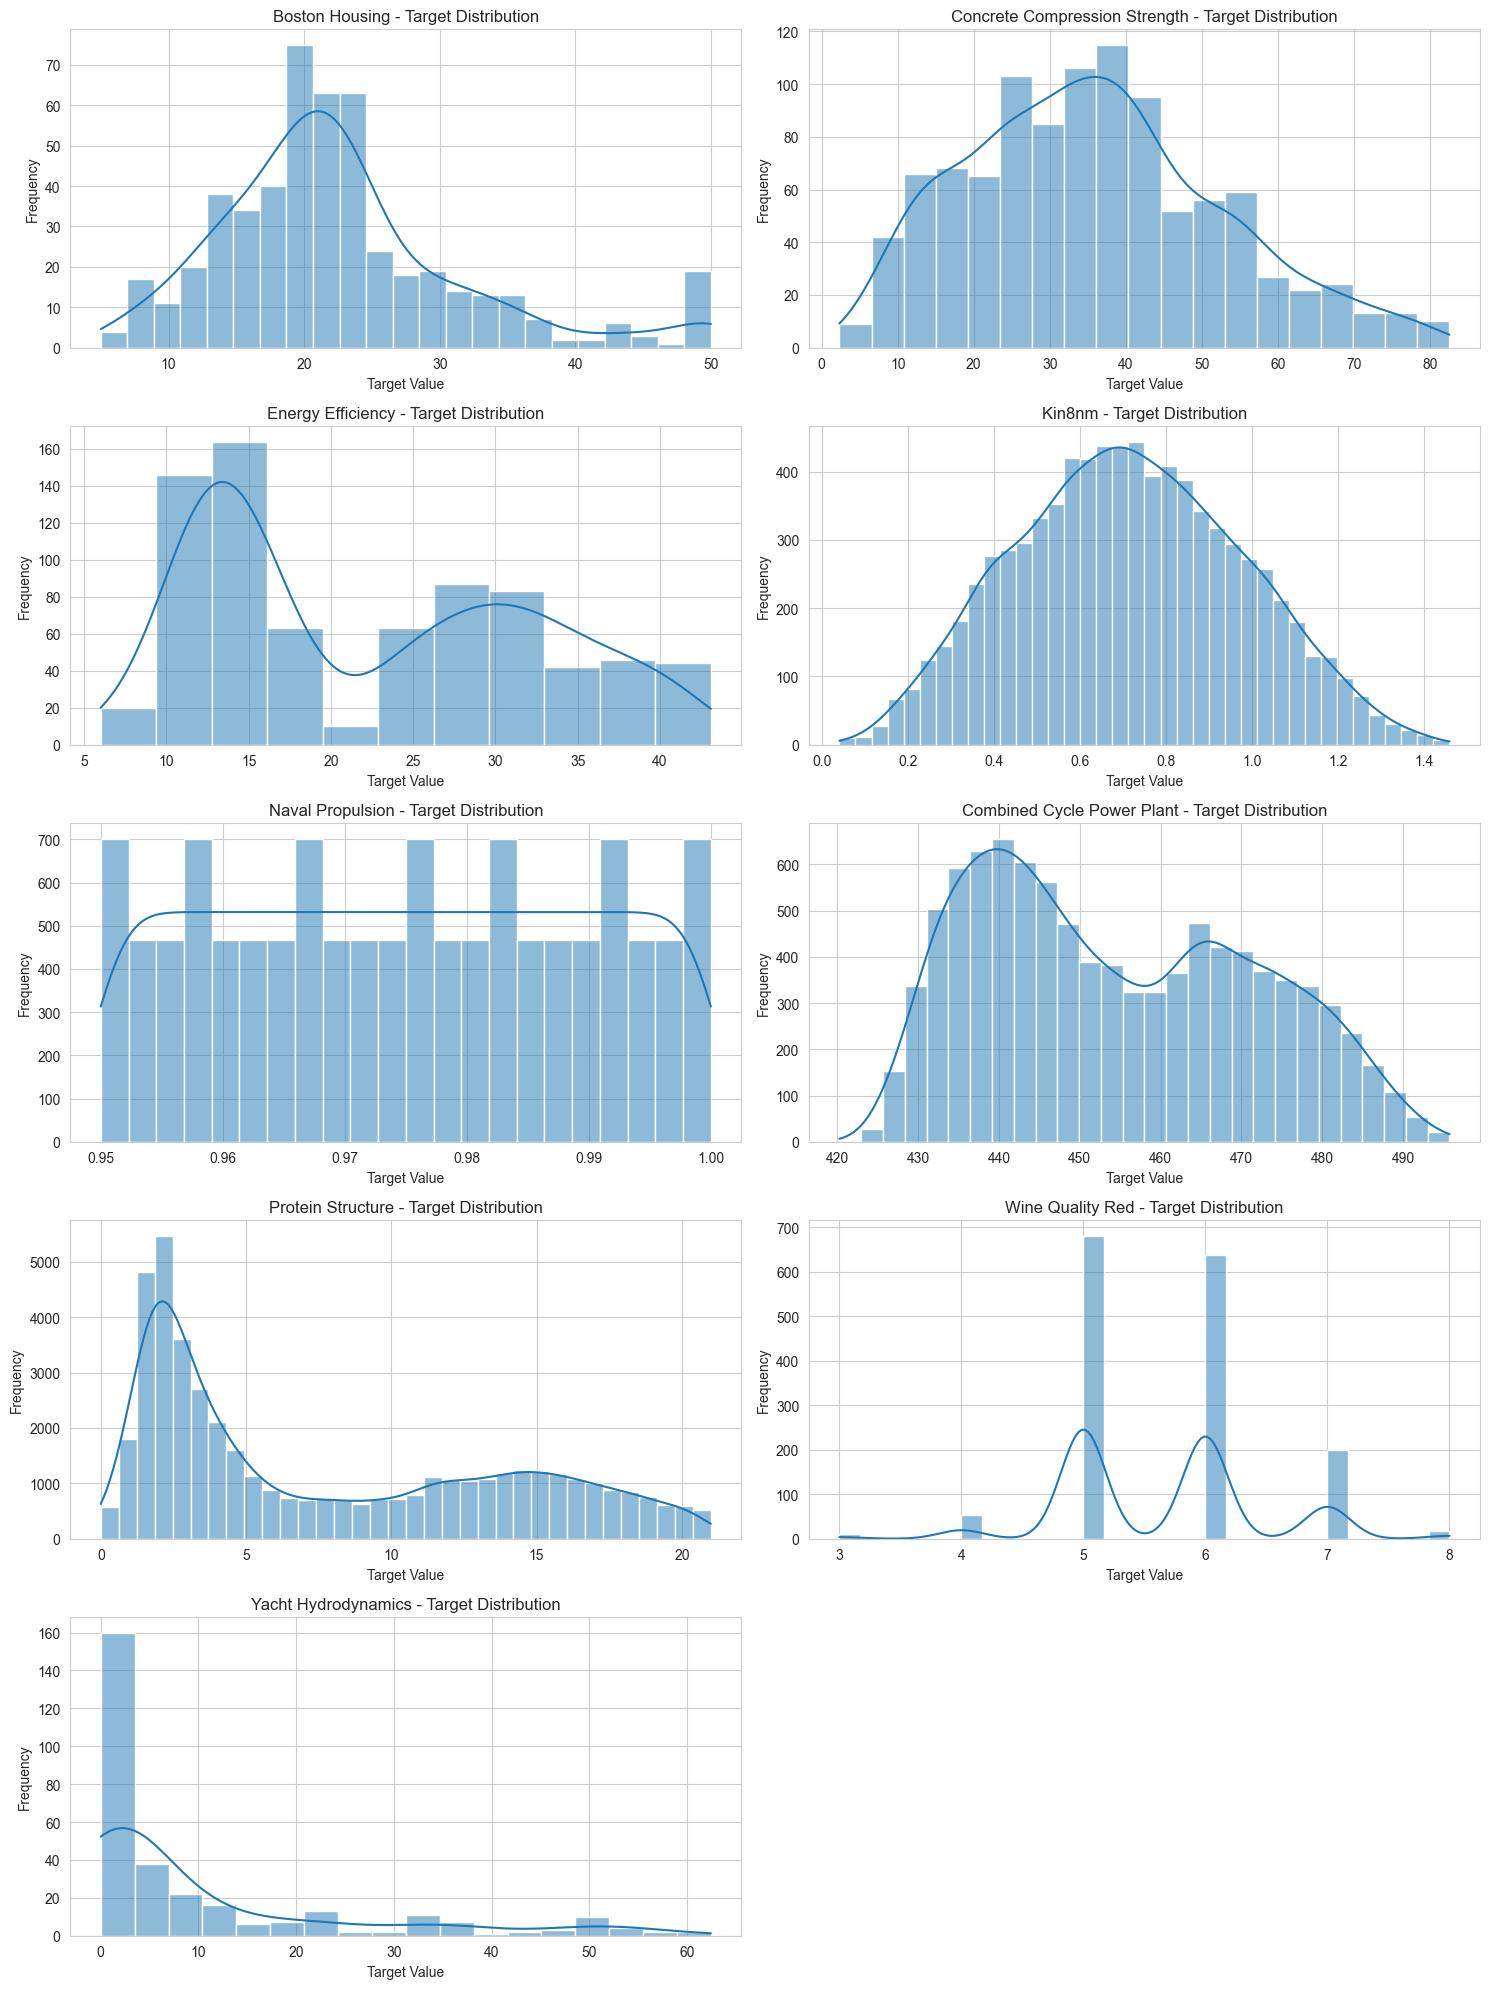

In [10]:
# Create a grid of histograms for target distributions
n_datasets = len(datasets_data)
n_cols = 2
n_rows = (n_datasets + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, (dataset_name, data) in enumerate(datasets_data.items()):
    y = data.iloc[:, -1]
    
    # Plot histogram with KDE
    sns.histplot(y, kde=True, ax=axes[i])
    
    # Add QQ plot as an insert to check normality
    from scipy import stats
    #ax_inset = axes[i].inset_axes([0.6, 0.6, 0.35, 0.35])
    #stats.probplot(y, plot=ax_inset)
    #ax_inset.set_title('QQ Plot', fontsize=8)
    #ax_inset.tick_params(axis='both', which='both', labelsize=6)
    
    # Set titles and labels
    axes[i].set_title(f"{dataset_name} - Target Distribution")
    axes[i].set_xlabel('Target Value')
    axes[i].set_ylabel('Frequency')
    
    # Add skewness and kurtosis as text
    # skew = y.skew()
    # kurt = y.kurtosis()
    # stats_text = f"Skewness: {skew:.2f}\nKurtosis: {kurt:.2f}"
    # axes[i].text(0.05, 0.95, stats_text, transform=axes[i].transAxes, 
    #              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Feature Distributions for Each Dataset

Let's examine the distribution of features in each dataset:


## Boston Housing Feature Distributions
Dataset has 13 features. Showing only the first 10.


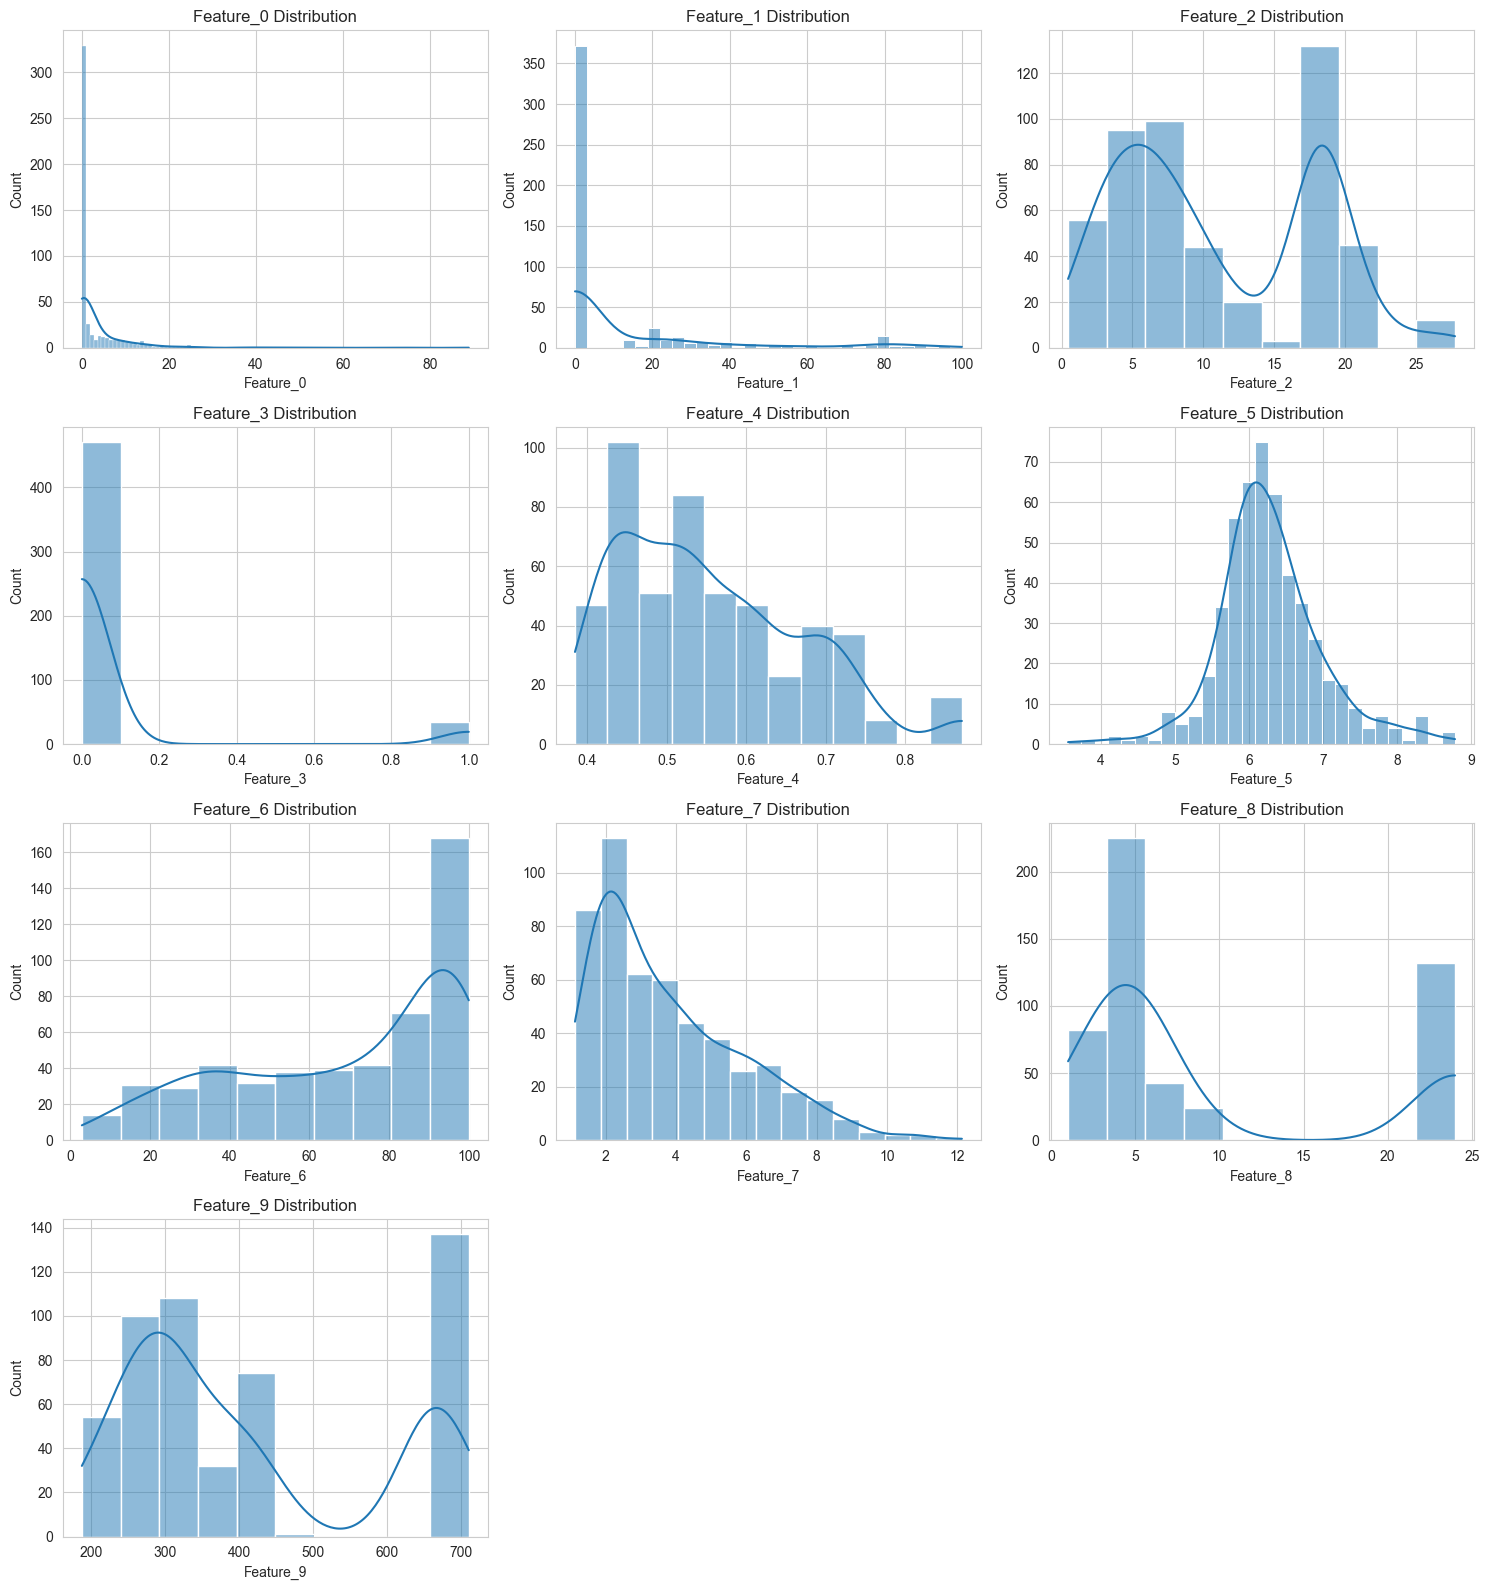

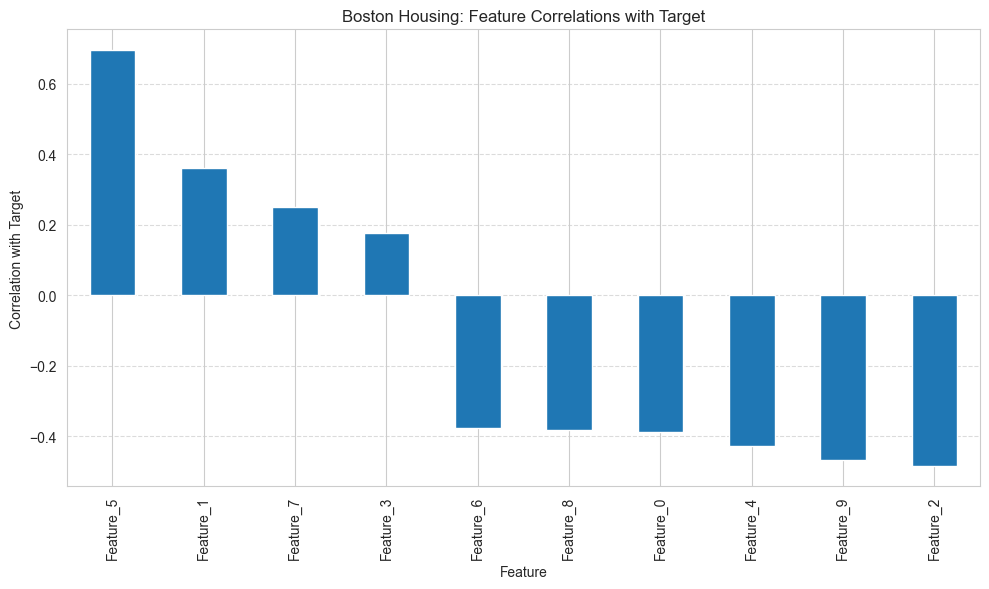


## Concrete Compression Strength Feature Distributions


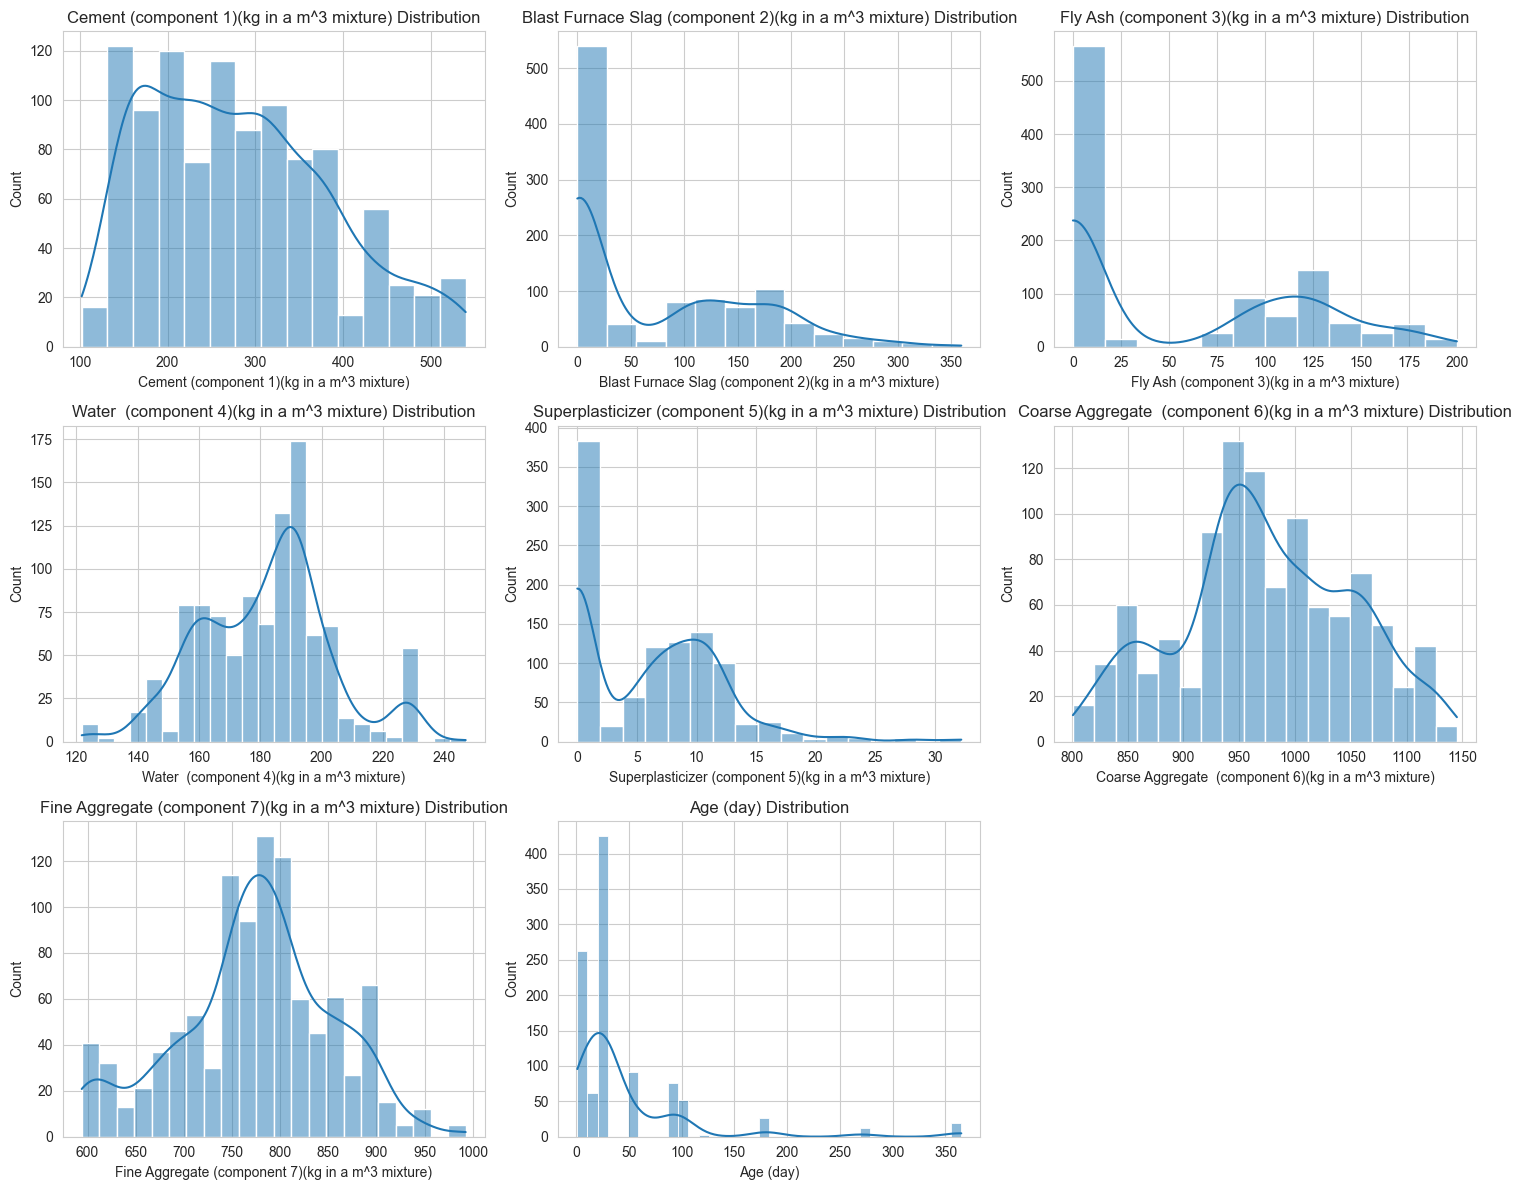

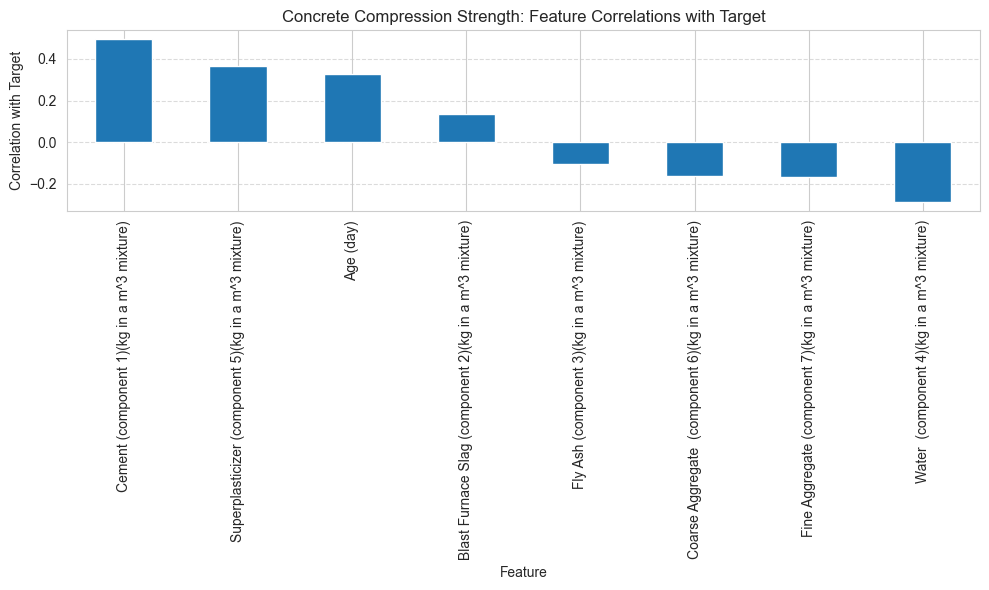


## Energy Efficiency Feature Distributions


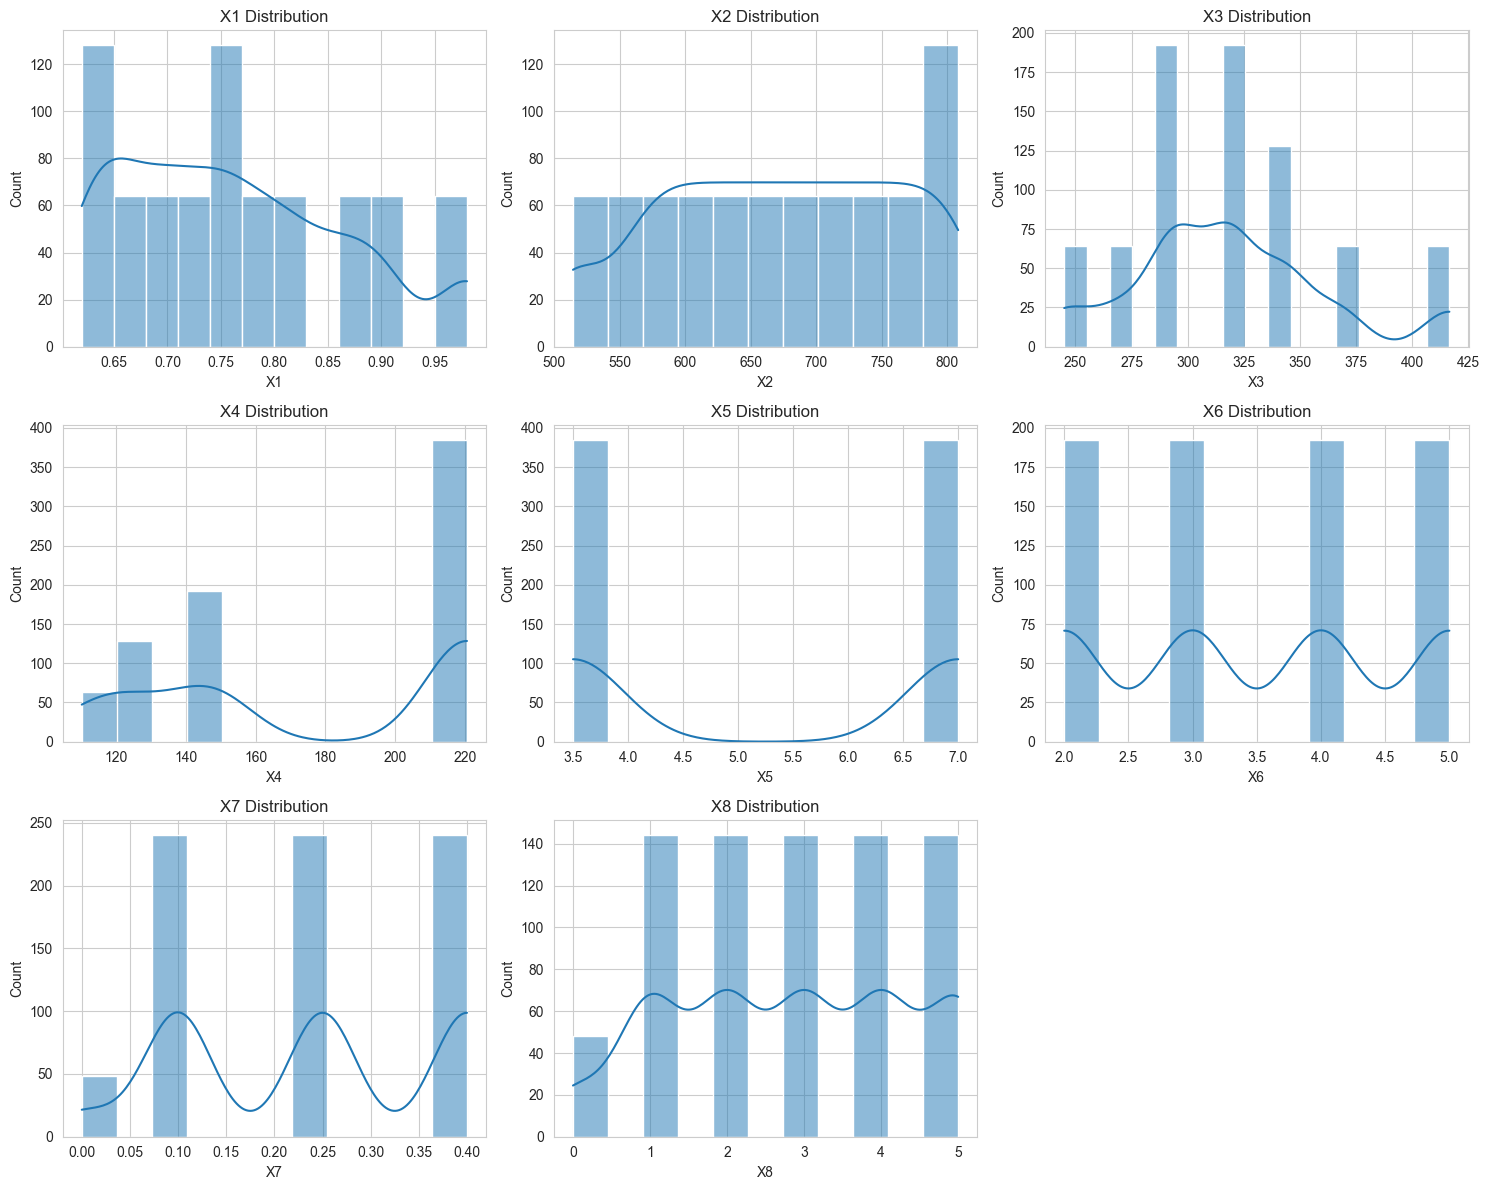

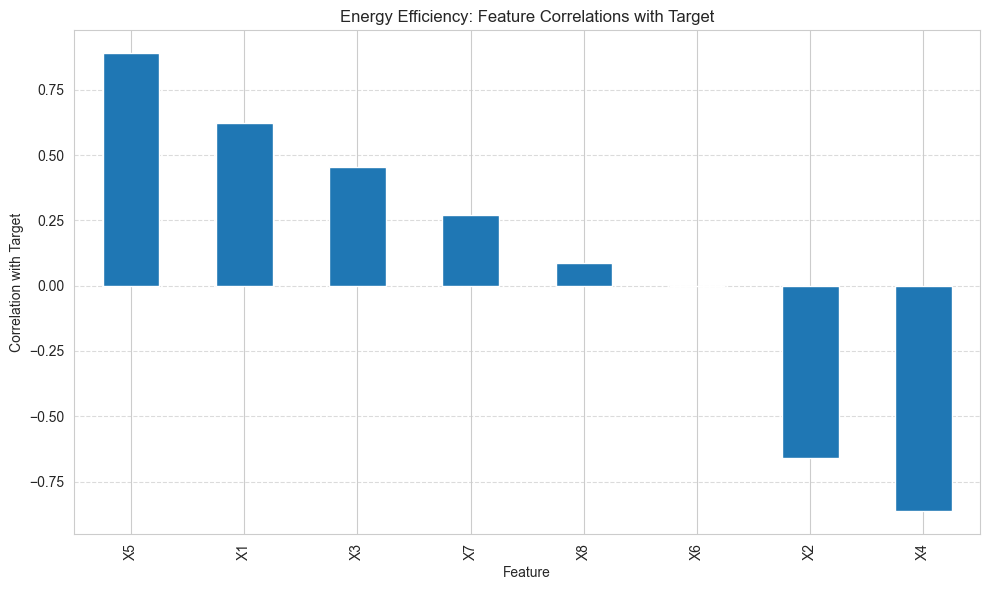

In [5]:
# Function to plot feature distributions for a dataset
def plot_feature_distributions(dataset_name, data):
    print(f"\n## {dataset_name} Feature Distributions")
    
    # Get feature names
    if all(isinstance(col, int) for col in data.columns):
        # If columns are integers (no header), rename them
        data.columns = [f'Feature_{i}' if i < len(data.columns)-1 else 'Target' for i in range(len(data.columns))]
    
    X = data.iloc[:, :-1]
    n_features = X.shape[1]
    
    # Limit to first 10 features if there are too many
    if n_features > 10:
        print(f"Dataset has {n_features} features. Showing only the first 10.")
        X = X.iloc[:, :10]
        n_features = 10
    
    # Create subplot grid
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Plot each feature
    for i, col in enumerate(X.columns):
        sns.histplot(X[col], kde=True, ax=axes[i])
        axes[i].set_title(f"{col} Distribution")
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation with target
    y = data.iloc[:, -1]
    correlations = X.corrwith(y).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    correlations.plot(kind='bar')
    plt.title(f"{dataset_name}: Feature Correlations with Target")
    plt.xlabel('Feature')
    plt.ylabel('Correlation with Target')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot for each dataset (limited to first 3 to avoid notebook getting too large)
for i, (dataset_name, data) in enumerate(list(datasets_data.items())[:3]):
    plot_feature_distributions(dataset_name, data)

## Target Distribution Analysis with Potential Statistical Distributions

Let's fit several statistical distributions to the target variables to see which one fits best:


Analyzing Boston Housing


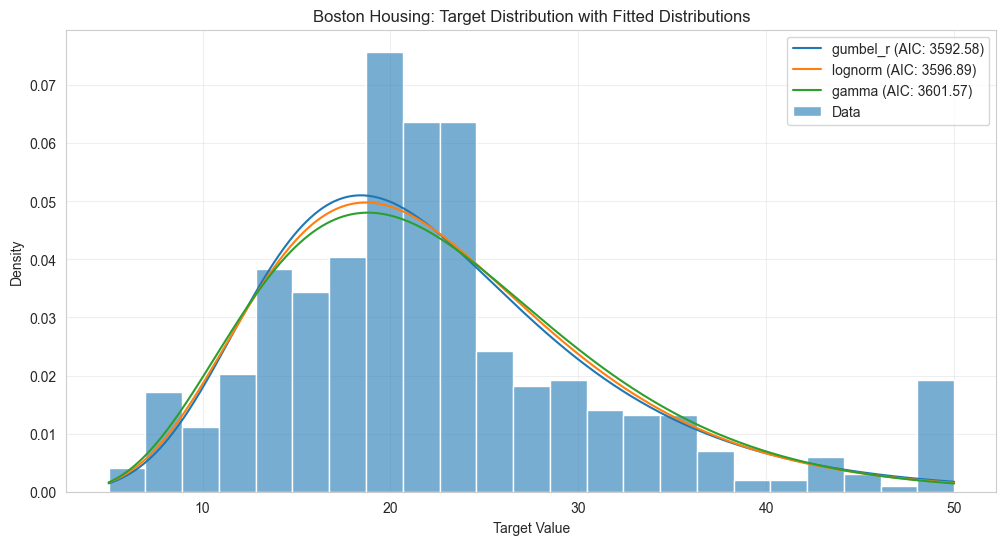


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood          AIC          BIC
5     gumbel_r    -1794.292065  3592.584130  3601.037203
3      lognorm    -1795.444706  3596.889412  3609.569022
2        gamma    -1797.785203  3601.570406  3614.250016
6      laplace    -1806.258701  3616.517402  3624.970476
4  weibull_min    -1807.915305  3621.830611  3634.510221
1            t    -1816.819737  3639.639475  3652.319085
0         norm    -1840.240066  3684.480131  3692.933205

Analyzing Concrete Compression Strength


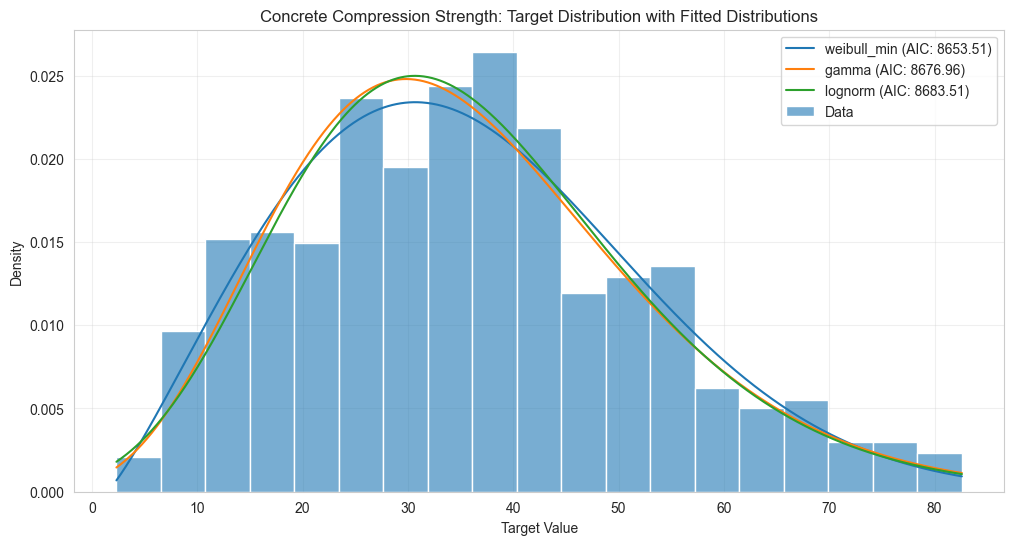


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood          AIC          BIC
4  weibull_min    -4323.756202  8653.512403  8668.324345
2        gamma    -4335.478821  8676.957642  8691.769584
3      lognorm    -4338.754315  8683.508630  8698.320572
5     gumbel_r    -4350.296392  8704.592784  8714.467412
0         norm    -4361.227640  8726.455280  8736.329909
1            t    -4361.228111  8728.456222  8743.268164
6      laplace    -4419.121098  8842.242196  8852.116825

Analyzing Energy Efficiency


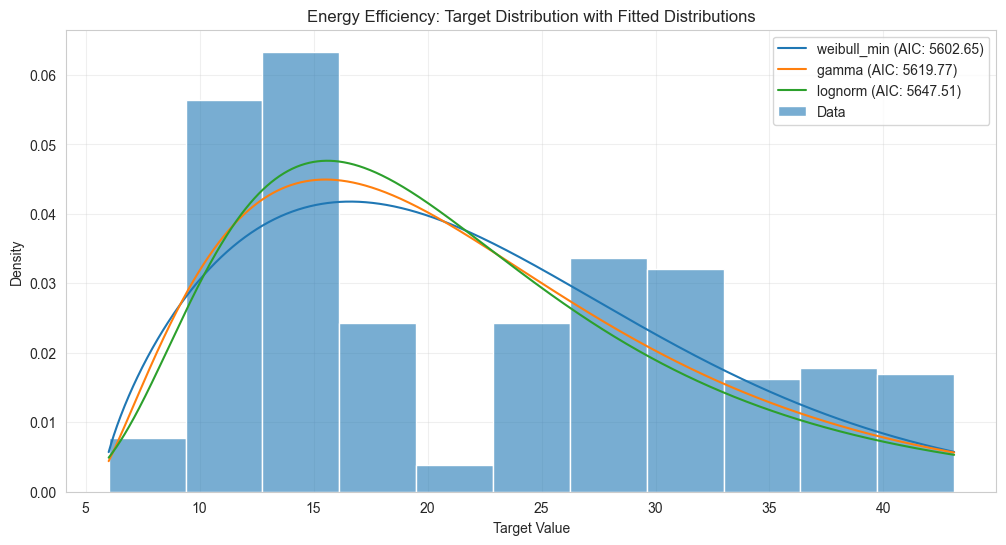


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood          AIC          BIC
4  weibull_min    -2798.323337  5602.646674  5616.578043
2        gamma    -2806.884229  5619.768459  5633.699828
3      lognorm    -2820.752578  5647.505157  5661.436526
5     gumbel_r    -2832.813685  5669.627370  5678.914950
0         norm    -2864.526426  5733.052851  5742.340431
1            t    -2864.526431  5735.052861  5748.984231
6      laplace    -2990.770225  5985.540450  5994.828029

Analyzing Kin8nm


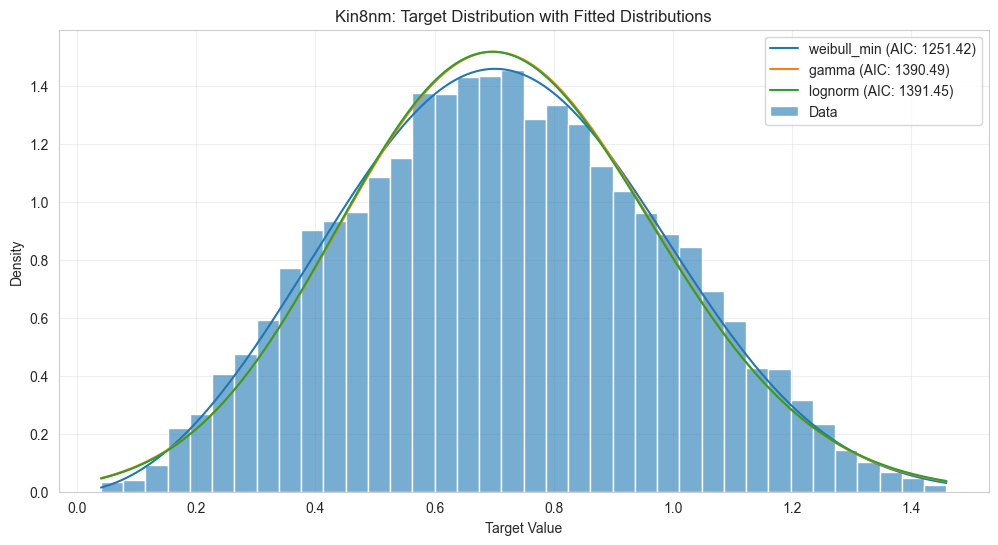


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood          AIC          BIC
4  weibull_min     -622.709689  1251.419379  1272.452119
2        gamma     -692.246241  1390.492483  1411.525223
3      lognorm     -692.722908  1391.445816  1412.478556
0         norm     -701.077897  1406.155794  1420.177621
1            t     -701.077898  1408.155796  1429.188536
5     gumbel_r    -1057.428820  2118.857640  2132.879467
6      laplace    -1297.174563  2598.349126  2612.370952

Analyzing Naval Propulsion


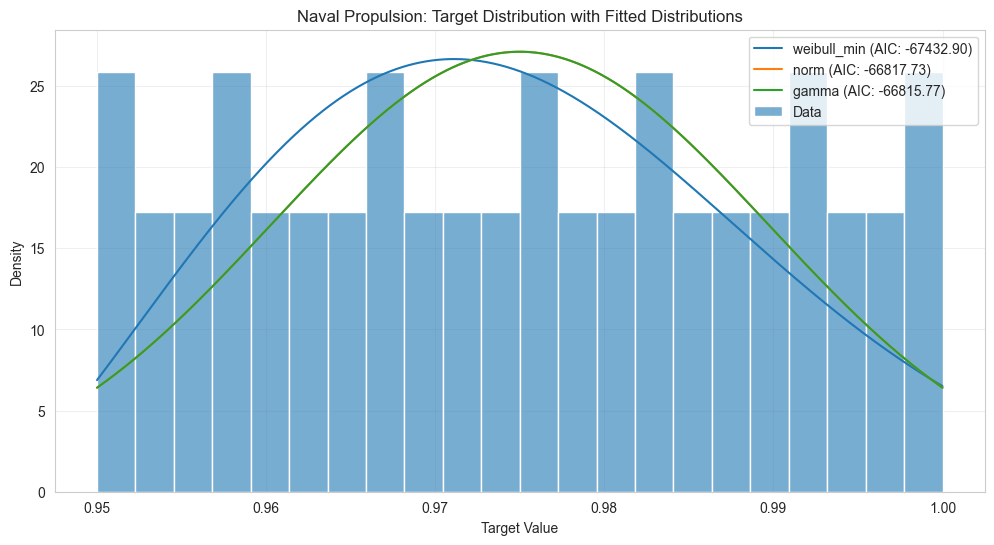


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood           AIC           BIC
4  weibull_min    33719.449212 -67432.898424 -67410.736984
0         norm    33410.864481 -66817.728962 -66802.954669
2        gamma    33410.884320 -66815.768639 -66793.607199
3      lognorm    33410.864481 -66815.728962 -66793.567522
1            t    33410.864481 -66815.728962 -66793.567521
5     gumbel_r    33043.372773 -66082.745547 -66067.971253
6      laplace    31857.351969 -63710.703938 -63695.929644

Analyzing Combined Cycle Power Plant


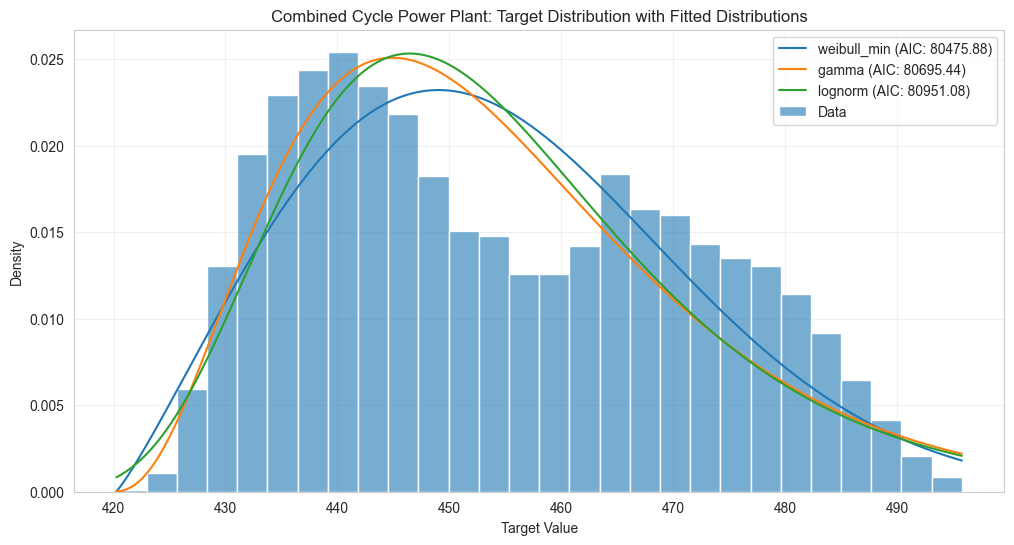


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood           AIC           BIC
4  weibull_min   -40234.942226  80475.884451  80497.382990
2        gamma   -40344.719627  80695.439254  80716.937792
3      lognorm   -40472.537557  80951.075113  80972.573652
5     gumbel_r   -40534.977136  81073.954272  81088.286631
0         norm   -40721.721394  81447.442788  81461.775147
1            t   -40721.960570  81449.921139  81471.419678
6      laplace   -41931.294507  83866.589014  83880.921373

Analyzing Protein Structure


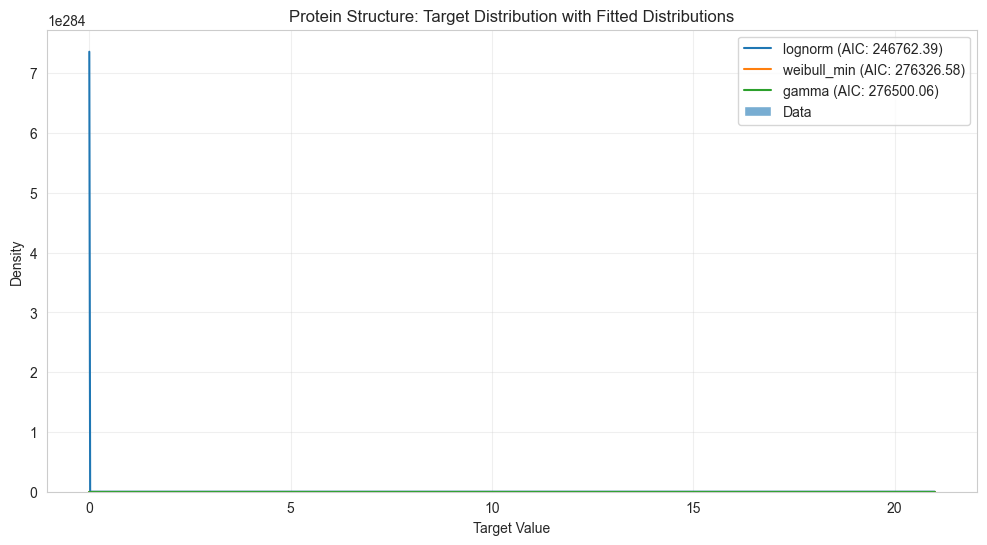


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood            AIC            BIC
3      lognorm  -123378.194828  246762.389656  246788.581186
4  weibull_min  -138160.287771  276326.575542  276352.767071
2        gamma  -138247.029157  276500.058313  276526.249842
5     gumbel_r  -143783.574058  287571.148116  287588.609136
0         norm  -147717.676515  295439.353030  295456.814050
1            t  -147717.676520  295441.353041  295467.544570
6      laplace  -153279.553422  306563.106844  306580.567864

Analyzing Wine Quality Red


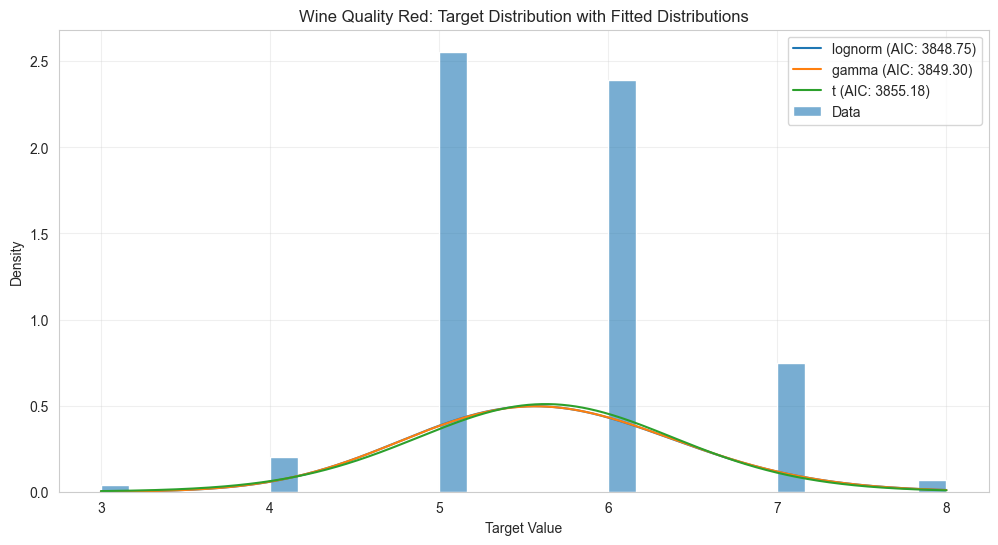


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood          AIC          BIC
3      lognorm    -1921.373234  3848.746469  3864.877870
2        gamma    -1921.650375  3849.300750  3865.432151
1            t    -1924.587752  3855.175505  3871.306906
0         norm    -1926.634310  3857.268620  3868.022887
5     gumbel_r    -2037.388398  4078.776796  4089.531064
6      laplace    -2037.864516  4079.729032  4090.483299
4  weibull_min            -inf          inf          inf

Analyzing Yacht Hydrodynamics


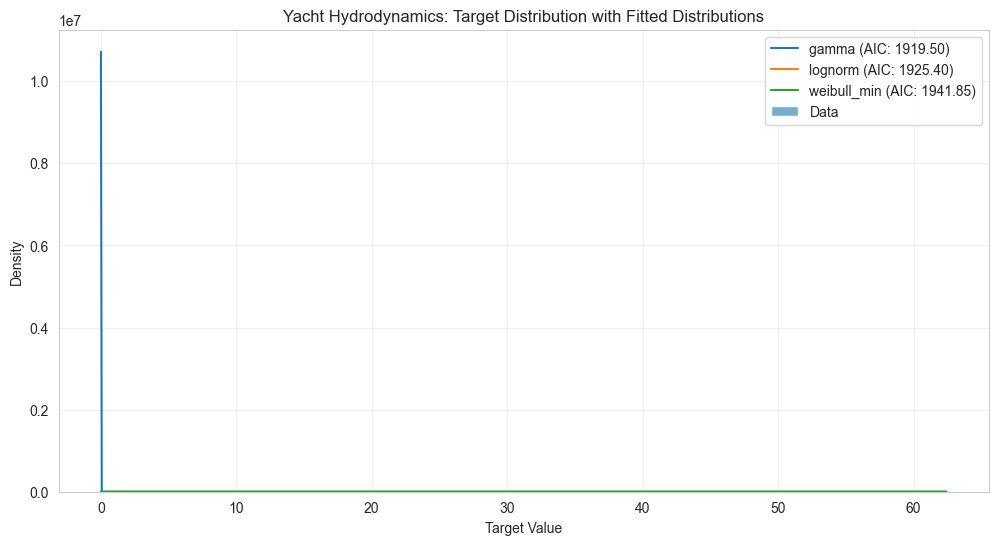


Distribution Fitting Results (sorted by AIC):
  Distribution  Log-Likelihood          AIC          BIC
2        gamma     -956.752057  1919.504113  1930.694413
3      lognorm     -959.702297  1925.404594  1936.594893
4  weibull_min     -967.922677  1941.845355  1953.035654
1            t    -1137.965922  2281.931843  2293.122142
5     gumbel_r    -1177.960710  2359.921420  2367.381620
6      laplace    -1213.091454  2430.182909  2437.643109
0         norm    -1273.889609  2551.779218  2559.239417


In [6]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# List of distributions to try
distributions = [stats.norm, stats.t, stats.gamma, stats.lognorm, 
                 stats.weibull_min, stats.gumbel_r, stats.laplace]

# Function to fit distributions and calculate AIC
def fit_distributions(data):
    results = []
    
    for dist in distributions:
        try:
            # Fit distribution
            params = dist.fit(data)
            
            # Calculate log likelihood
            log_likelihood = np.sum(dist.logpdf(data, *params))
            
            # Calculate AIC: -2*log_likelihood + 2*k (k=number of parameters)
            k = len(params)
            aic = -2 * log_likelihood + 2 * k
            
            # Calculate BIC: -2*log_likelihood + k*ln(n)
            n = len(data)
            bic = -2 * log_likelihood + k * np.log(n)
            
            results.append({
                'Distribution': dist.name,
                'Log-Likelihood': log_likelihood,
                'AIC': aic,
                'BIC': bic,
                'Params': params
            })
        except Exception as e:
            print(f"Error fitting {dist.name}: {str(e)}")
    
    return pd.DataFrame(results).sort_values('AIC')

# Function to plot data with fitted distributions
def plot_with_fitted_distributions(dataset_name, data, top_n=3):
    y = data.iloc[:, -1]
    
    # Fit distributions
    fit_results = fit_distributions(y)
    
    # Plot histogram of data
    plt.figure(figsize=(12, 6))
    sns.histplot(y, kde=False, stat='density', alpha=0.6, label='Data')
    
    # Plot top distributions
    x = np.linspace(min(y), max(y), 1000)
    for i, row in fit_results.head(top_n).iterrows():
        dist_name = row['Distribution']
        dist = getattr(stats, dist_name)
        params = row['Params']
        
        # Plot PDF
        pdf = dist.pdf(x, *params)
        plt.plot(x, pdf, label=f"{dist_name} (AIC: {row['AIC']:.2f})")
    
    plt.title(f"{dataset_name}: Target Distribution with Fitted Distributions")
    plt.xlabel('Target Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    # Print table of results
    print("\nDistribution Fitting Results (sorted by AIC):")
    print(fit_results[['Distribution', 'Log-Likelihood', 'AIC', 'BIC']])
    
    return fit_results

# Analyze each dataset
all_results = {}
for dataset_name, data in datasets_data.items():
    print(f"\n{'='*60}")
    print(f"Analyzing {dataset_name}")
    print(f"{'='*60}")
    all_results[dataset_name] = plot_with_fitted_distributions(dataset_name, data)

## Summary of Best Fitting Distributions

Let's summarize which distribution fits best for each dataset:

In [7]:
# Create summary table
summary_data = []
for dataset_name, fit_results in all_results.items():
    best_dist = fit_results.iloc[0]
    y = datasets_data[dataset_name].iloc[:, -1]
    
    summary_data.append({
        'Dataset': dataset_name,
        'Best Distribution': best_dist['Distribution'],
        'AIC': best_dist['AIC'],
        'BIC': best_dist['BIC'],
        'Log-Likelihood': best_dist['Log-Likelihood'],
        'Sample Size': len(y),
        'Target Mean': y.mean(),
        'Target Std': y.std(),
        'Target Skewness': y.skew(),
        'Target Kurtosis': y.kurt()
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Dataset,Best Distribution,AIC,BIC,Log-Likelihood,Sample Size,Target Mean,Target Std,Target Skewness,Target Kurtosis
0,Boston Housing,gumbel_r,3592.584130,3601.037203,-1794.292065,506,22.532806,9.197104,1.108098,1.495197
1,Concrete Compression Strength,weibull_min,8653.512403,8668.324345,-4323.756202,1030,35.817836,16.705679,0.416922,-0.313844
2,Energy Efficiency,weibull_min,5602.646674,5616.578043,-2798.323337,768,22.307195,10.090204,0.360446,-1.245569
3,Kin8nm,weibull_min,1251.419379,1272.452119,-622.709689,8192,0.714283,0.263607,0.090308,-0.533795
4,Naval Propulsion,weibull_min,-67432.898424,-67410.736984,33719.449212,11934,0.975000,0.014720,0.000000,-1.200923
5,Combined Cycle Power Plant,weibull_min,80475.884451,80497.382990,-40234.942226,9568,454.365009,17.066995,0.306509,-1.048521
6,Protein Structure,lognorm,246762.389656,246788.581186,-123378.194828,45730,7.748528,6.118312,0.566522,-1.142129
7,Wine Quality Red,lognorm,3848.746469,3864.877870,-1921.373234,1599,5.636023,0.807569,0.217802,0.296708
8,Yacht Hydrodynamics,gamma,1919.504113,1930.694413,-956.752057,308,10.495357,15.160490,1.756314,2.049840


## Dataset Comparison: Visualization of Properties

Let's create some visualizations to compare key properties across datasets:

<Figure size 1200x600 with 0 Axes>

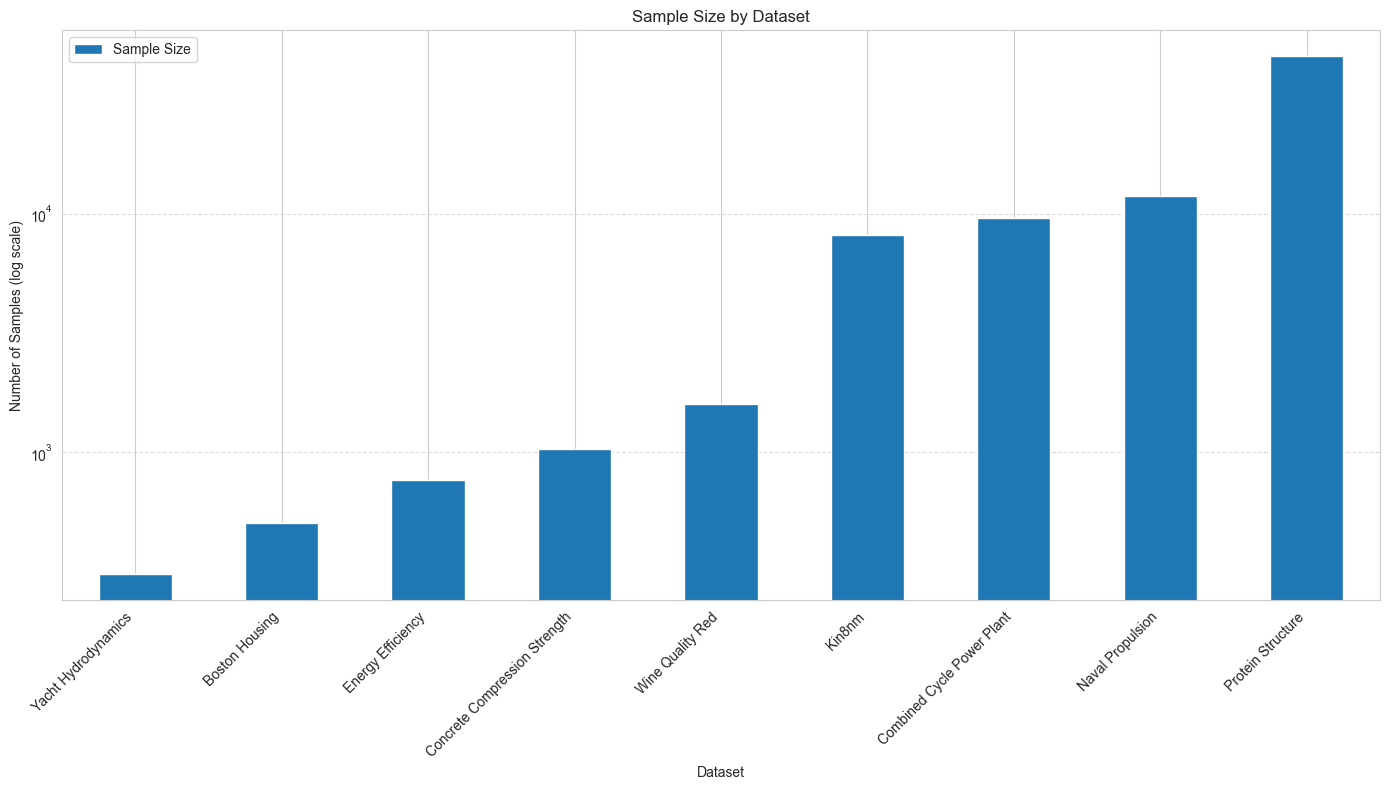

<Figure size 1200x600 with 0 Axes>

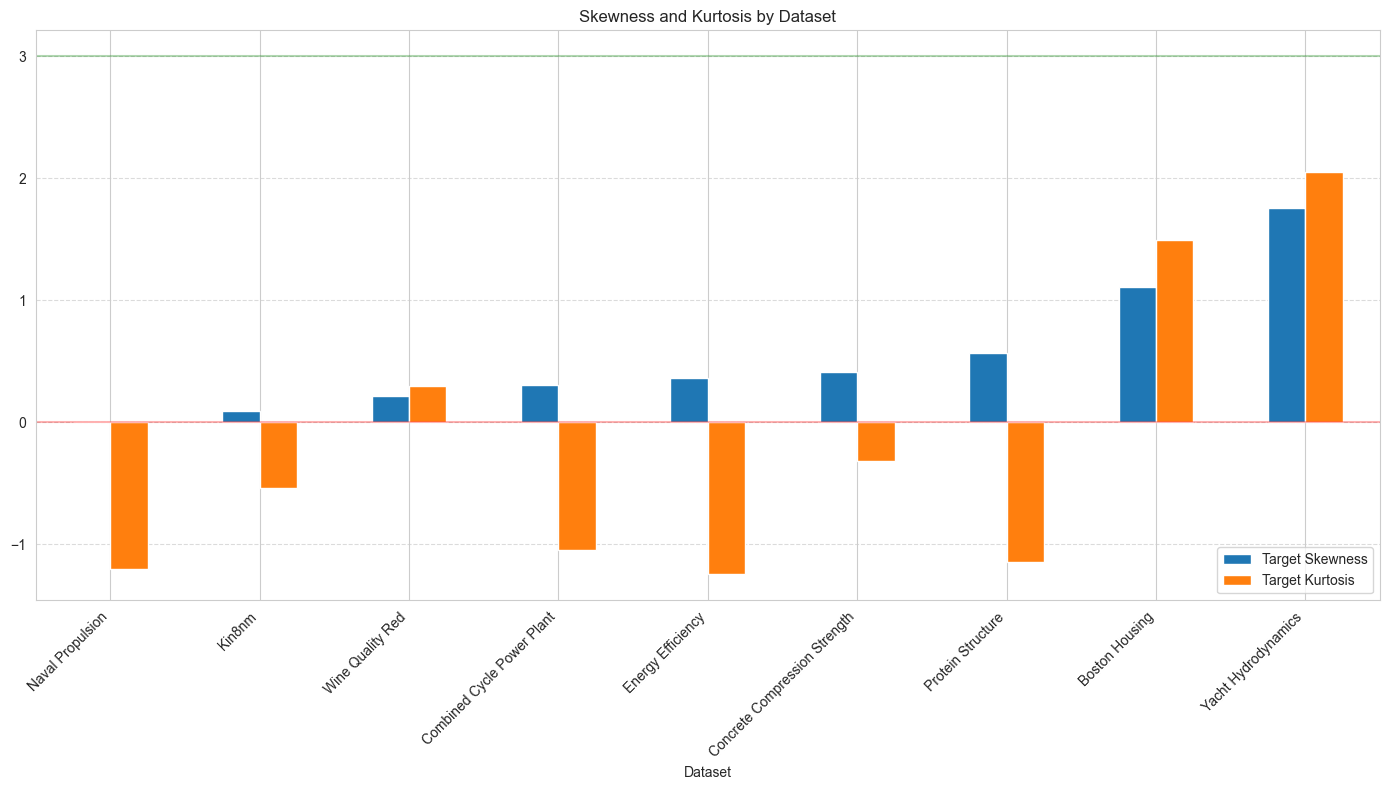

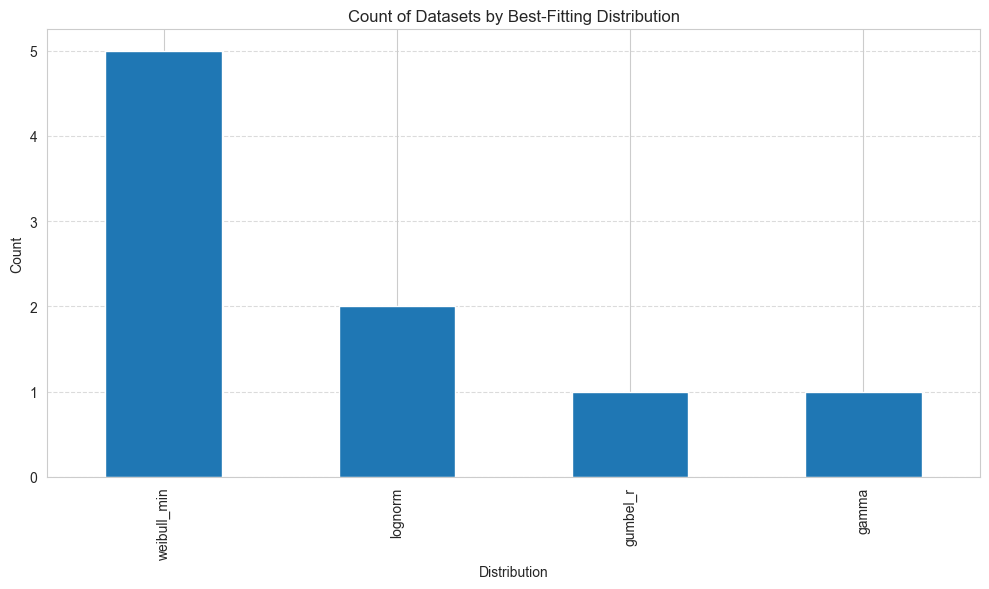

In [8]:
# Plot sample sizes
plt.figure(figsize=(12, 6))
summary_df.sort_values('Sample Size').plot(x='Dataset', y='Sample Size', kind='bar')
plt.title('Sample Size by Dataset')
plt.ylabel('Number of Samples (log scale)')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot skewness and kurtosis
plt.figure(figsize=(12, 6))
summary_df.sort_values('Target Skewness').plot(x='Dataset', y=['Target Skewness', 'Target Kurtosis'], kind='bar')
plt.title('Skewness and Kurtosis by Dataset')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)  # Reference line for normal distribution (skewness=0)
plt.axhline(y=3, color='g', linestyle='-', alpha=0.3)  # Reference line for normal distribution (kurtosis=3)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribution count
dist_counts = summary_df['Best Distribution'].value_counts()
plt.figure(figsize=(10, 6))
dist_counts.plot(kind='bar')
plt.title('Count of Datasets by Best-Fitting Distribution')
plt.xlabel('Distribution')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

This analysis provides insights into the distributional characteristics of the UCI datasets used in LSS-boost experiments. The visualization shows which probability distributions best fit each dataset's target variable, which can help inform modeling choices in probabilistic regression tasks.

Key observations:
1. Most datasets are not perfectly normally distributed
2. Different datasets are best modeled by different probability distributions
3. There is significant variation in sample sizes across datasets
4. Several datasets exhibit significant skewness and non-normal kurtosis

These insights support the use of flexible distribution models like those employed in LSS-boost rather than assuming normality for all datasets.